### Polynomial regression implementation


In [2]:
## import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
X = 6 * np.random.rand(100, 1) - 3

# Quadratic Equation: 0.5x^2 + 1.5x + 2 + outliers
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)


Text(0, 0.5, 'Y dataset')

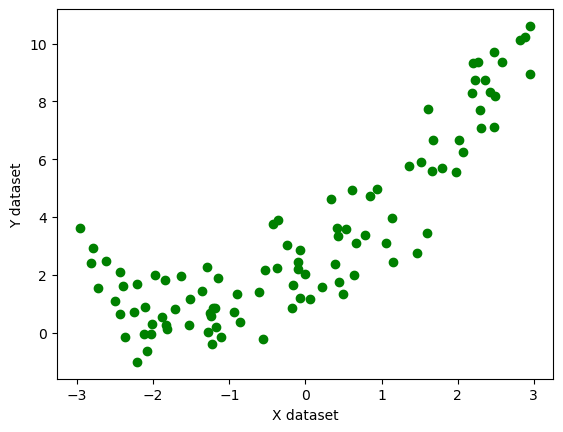

In [4]:
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
## Lets implement a simple linear regression

from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

regression_1.fit(X_train, y_train)


LinearRegression()

In [7]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
print(score)  # bad score as plt shows its following parabola and we are trying to find best fit line

0.7397332423841836


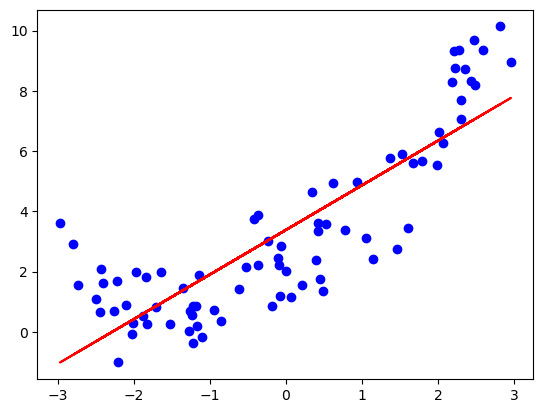

In [8]:
## Lets visualize this model

plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train, c='blue')

In [9]:
## Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [10]:
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8984308228661962


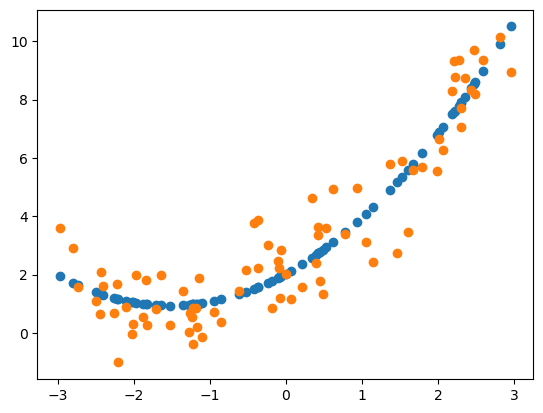

In [12]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [13]:
poly = PolynomialFeatures(degree=3, include_bias=True)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [14]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9027013241548868


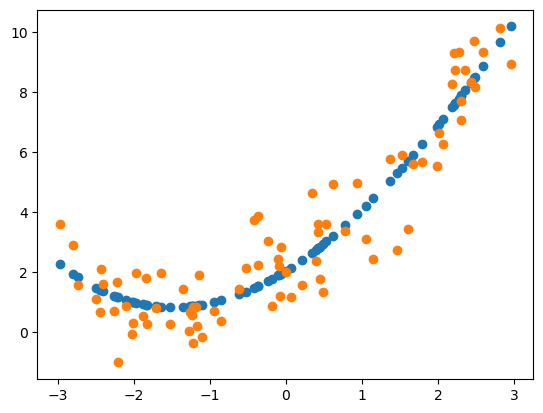

In [15]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [16]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

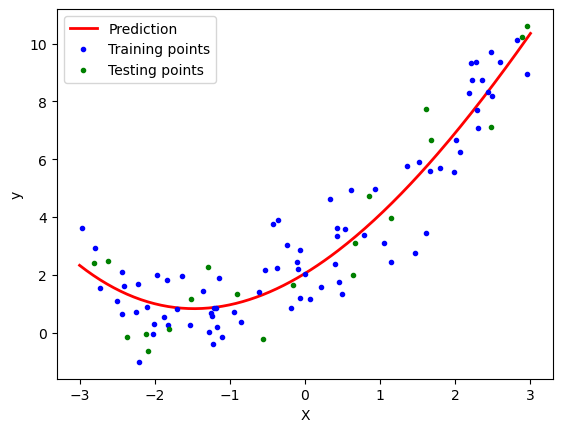

In [20]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth="2", label="Prediction")
plt.plot(X_train, y_train, "b.", label="Training points")
plt.plot(X_test, y_test, "g.", label="Testing points") 

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [21]:
from sklearn.pipeline import Pipeline

In [23]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_regression = LinearRegression()
    poly_regression = Pipeline([
        ('poly_features', poly_features),
        ("lin_regression", lin_regression)
    ])
    
    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict(X_new)
    
    ## Plotting prediction line
    plt.plot(X_new, y_pred_new, "r", label="Degree "+str(degree), linewidth=3)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "r.", linewidth=3)
    
    plt.legend(loc="Upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

ValueError: 'Upper left' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

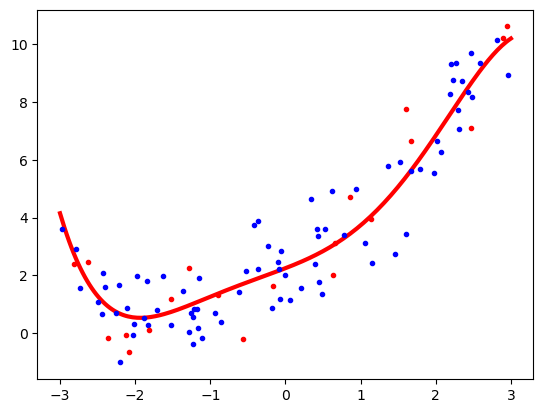

In [24]:
poly_regression(5)